In [1]:
# ===== CHANGE THESE TWO LINES =====
IMAGE_PATH = r'/home/david/coin/WhatsApp Image 2026-05-31 at 11.24.34.jpeg'
TOPK = 5          # how many predictions to show
# ===================================

DATA_DIR     = r'/home/david/coin/FOR_TRAINNING'
ENSEMBLE_PTH = r'/home/david/coin/weights/emp_model_v3_TTA_ensemble.pth'


In [2]:
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from pathlib import Path


In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda:0


In [4]:
# Rebuild the same 51-class label encoder used during v3 training.
MERGES = {'GORDIAN II': 'GORDIAN I'}

def folder_label(name):
    return re.sub(r'^\d+_', '', name)

unique_labels = sorted({folder_label(p.name) for p in Path(DATA_DIR).iterdir()
                        if p.is_dir() and (p / 'side_a').exists()})
kept = [n for n in unique_labels if n not in MERGES]
idx_to_label = {i: n for i, n in enumerate(kept)}
num_classes = len(idx_to_label)

name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}
print(f'{num_classes} classes ready.')


51 classes ready.


In [5]:
class CosineClassifier(nn.Module):
    def __init__(self, in_dim, n_cls):
        super().__init__()
        self.weight = nn.Parameter(torch.zeros(n_cls, in_dim))
        self.log_scale = nn.Parameter(torch.tensor(0.0))  # 0-dim scalar, matches checkpoint

    def forward(self, x):
        return torch.exp(self.log_scale) * (F.normalize(x, dim=-1) @ F.normalize(self.weight, dim=-1).T)


class CoinHead(nn.Module):
    def __init__(self, in_dim=2560, n_cls=51, hidden=1024):
        super().__init__()
        self.body = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(0.0),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(0.0),
        )
        self.cls = CosineClassifier(hidden, n_cls)

    def forward(self, x):
        return self.cls(self.body(x))


In [6]:
states = torch.load(ENSEMBLE_PTH, map_location=device)
ensemble = []
for sd in states:
    m = CoinHead(in_dim=2560, n_cls=num_classes).to(device)
    m.load_state_dict(sd)
    m.eval()
    ensemble.append(m)
print(f'Loaded {len(ensemble)}-head ensemble.')


Loaded 5-head ensemble.


In [7]:
print('Loading C-RADIO v4-H backbone...')
radio = torch.hub.load('NVlabs/RADIO', 'radio_model',
                       version='c-radio_v4-h', progress=True)
radio = radio.to(device).eval()
for p in radio.parameters():
    p.requires_grad = False
print('Backbone ready.')


Loading C-RADIO v4-H backbone...


Using cache found in /home/david/.cache/torch/hub/NVlabs_RADIO_main
/home/david/.cache/torch/hub/NVlabs_RADIO_main/hubconf.py:80: UserWarning: Unexpected keys in state dict: ['patch_generator._vis_cond.norm_mean', 'patch_generator._vis_cond.norm_std']
  warnings.warn(f'Unexpected keys in state dict: {key_warn.unexpected_keys}')


Backbone ready.


In [8]:
def predict_image(path, topk=5):
    """Run 4-view TTA on a single image and return top-k (label, prob) pairs."""
    path = str(path)
    views = [(256, False), (256, True), (384, False), (384, True)]

    averaged_emb = None
    for res, flip in views:
        img = Image.open(path).convert('RGB')
        img = img.resize((res, res), Image.BILINEAR)
        if flip:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        t = torch.from_numpy(np.array(img)).permute(2, 0, 1).float().div_(255.0)
        t = t.unsqueeze(0).to(device)
        with torch.no_grad():
            with torch.autocast('cuda', dtype=torch.bfloat16,
                                enabled=device.type == 'cuda'):
                emb, _ = radio(t)
            emb = emb.float()
        averaged_emb = emb if averaged_emb is None else averaged_emb + emb

    averaged_emb /= len(views)

    # ensemble soft-vote
    probs = None
    with torch.no_grad():
        for m in ensemble:
            p = F.softmax(m(averaged_emb), dim=-1)
            probs = p if probs is None else probs + p
    probs = (probs / len(ensemble)).squeeze(0).cpu()

    top_p, top_i = probs.topk(topk)
    return [(idx_to_label[int(i)], float(p)) for i, p in zip(top_i, top_p)]


results = predict_image(IMAGE_PATH, topk=TOPK)
print(f'\nTop {TOPK} predictions for: {Path(IMAGE_PATH).name}\n')
for rank, (name, prob) in enumerate(results, 1):
    bar = '#' * int(prob * 40)
    print(f'  {rank}. {name:<25}  {prob*100:5.1f}%  {bar}')



Top 5 predictions for: WhatsApp Image 2026-05-31 at 11.24.34.jpeg

  1. TITUS                       35.6%  ##############
  2. VITELLIUS                   13.9%  #####
  3. CLAUDIUS                     5.9%  ##
  4. DOMITIAN                     5.4%  ##
  5. COMMODUS                     5.2%  ##


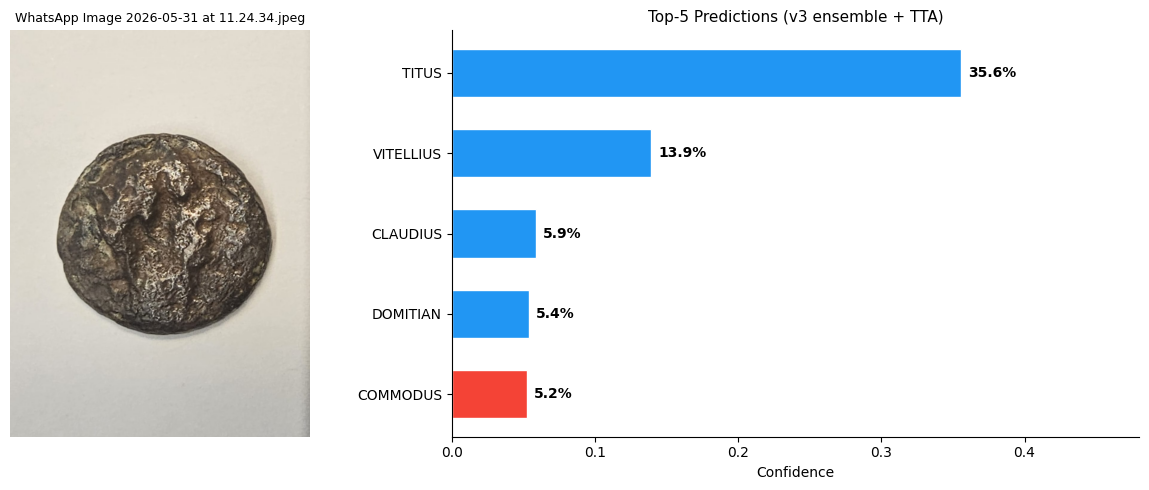

Saved -> /home/david/coin/outputs/prediction_result.png


In [9]:
# Display image and prediction bar chart side by side.
img_display = Image.open(IMAGE_PATH).convert('RGB')

fig, axes = plt.subplots(1, 2, figsize=(12, 5),
                         gridspec_kw={'width_ratios': [1, 1.8]})

axes[0].imshow(img_display)
axes[0].axis('off')
axes[0].set_title(Path(IMAGE_PATH).name, fontsize=9)

names  = [r[0] for r in results][::-1]
probs  = [r[1] for r in results][::-1]
colors = ['#2196F3' if i < len(results) - 1 else '#F44336' for i in range(len(results))]

bars = axes[1].barh(names, probs, color=colors[::-1], edgecolor='white', height=0.6)
for bar, p in zip(bars, probs):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{p*100:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlim(0, min(1.0, max(probs) * 1.35))
axes[1].set_xlabel('Confidence')
axes[1].set_title(f'Top-{TOPK} Predictions (v3 ensemble + TTA)', fontsize=11)
axes[1].axvline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('/home/david/coin/outputs/prediction_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> /home/david/coin/outputs/prediction_result.png')
